# Customer RFM Feature Engineering, Transformation & Scaling
### Olist Brazilian E-Commerce Dataset

This notebook covers:
1. Computing **RFM (Recency, Frequency, Monetary)** features for all unique customers.
2. Visualizing feature skewness via histograms and KDE curves.
3. Applying **Log Transformation** (`np.log`) to normalize the distributions.
4. Applying **StandardScaler** to scale features to $\mu=0, \sigma=1$ (`rfm_scaled`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Load Processed Master Dataset
data_path = os.path.join("..", "Data", "Processed", "df_master.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "df_master.csv")) else os.path.join("Data", "Processed", "df_master.csv")
df_master = pd.read_csv(data_path)
df_master["order_purchase_timestamp"] = pd.to_datetime(df_master["order_purchase_timestamp"])

print(f"Loaded df_master: {df_master.shape}")

Loaded df_master: (115035, 22)


## 2. Compute RFM Metrics

In [3]:
# Reference date = max order purchase timestamp + 1 day
reference_date = df_master["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = df_master.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda date: (reference_date - date.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("payment_value", "sum")
)

print(f"RFM Shape: {rfm.shape}")
display(rfm.head())

RFM Shape: (93357, 3)


,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


## 3. Visualize Raw Skewness vs. Log Transformation
Check skewness coefficients before and after log transform.

In [4]:
print("Raw RFM Skewness:")
display(rfm.skew())

# Apply Log Transformation
rfm_log = np.log(rfm)

print("\nLog-Transformed Skewness:")
display(rfm_log.skew())

Raw RFM Skewness:


Recency       0.447277
Frequency    11.095096
Monetary     70.336263
dtype: float64


Log-Transformed Skewness:


Recency     -1.289010
Frequency    6.091337
Monetary     0.727013
dtype: float64

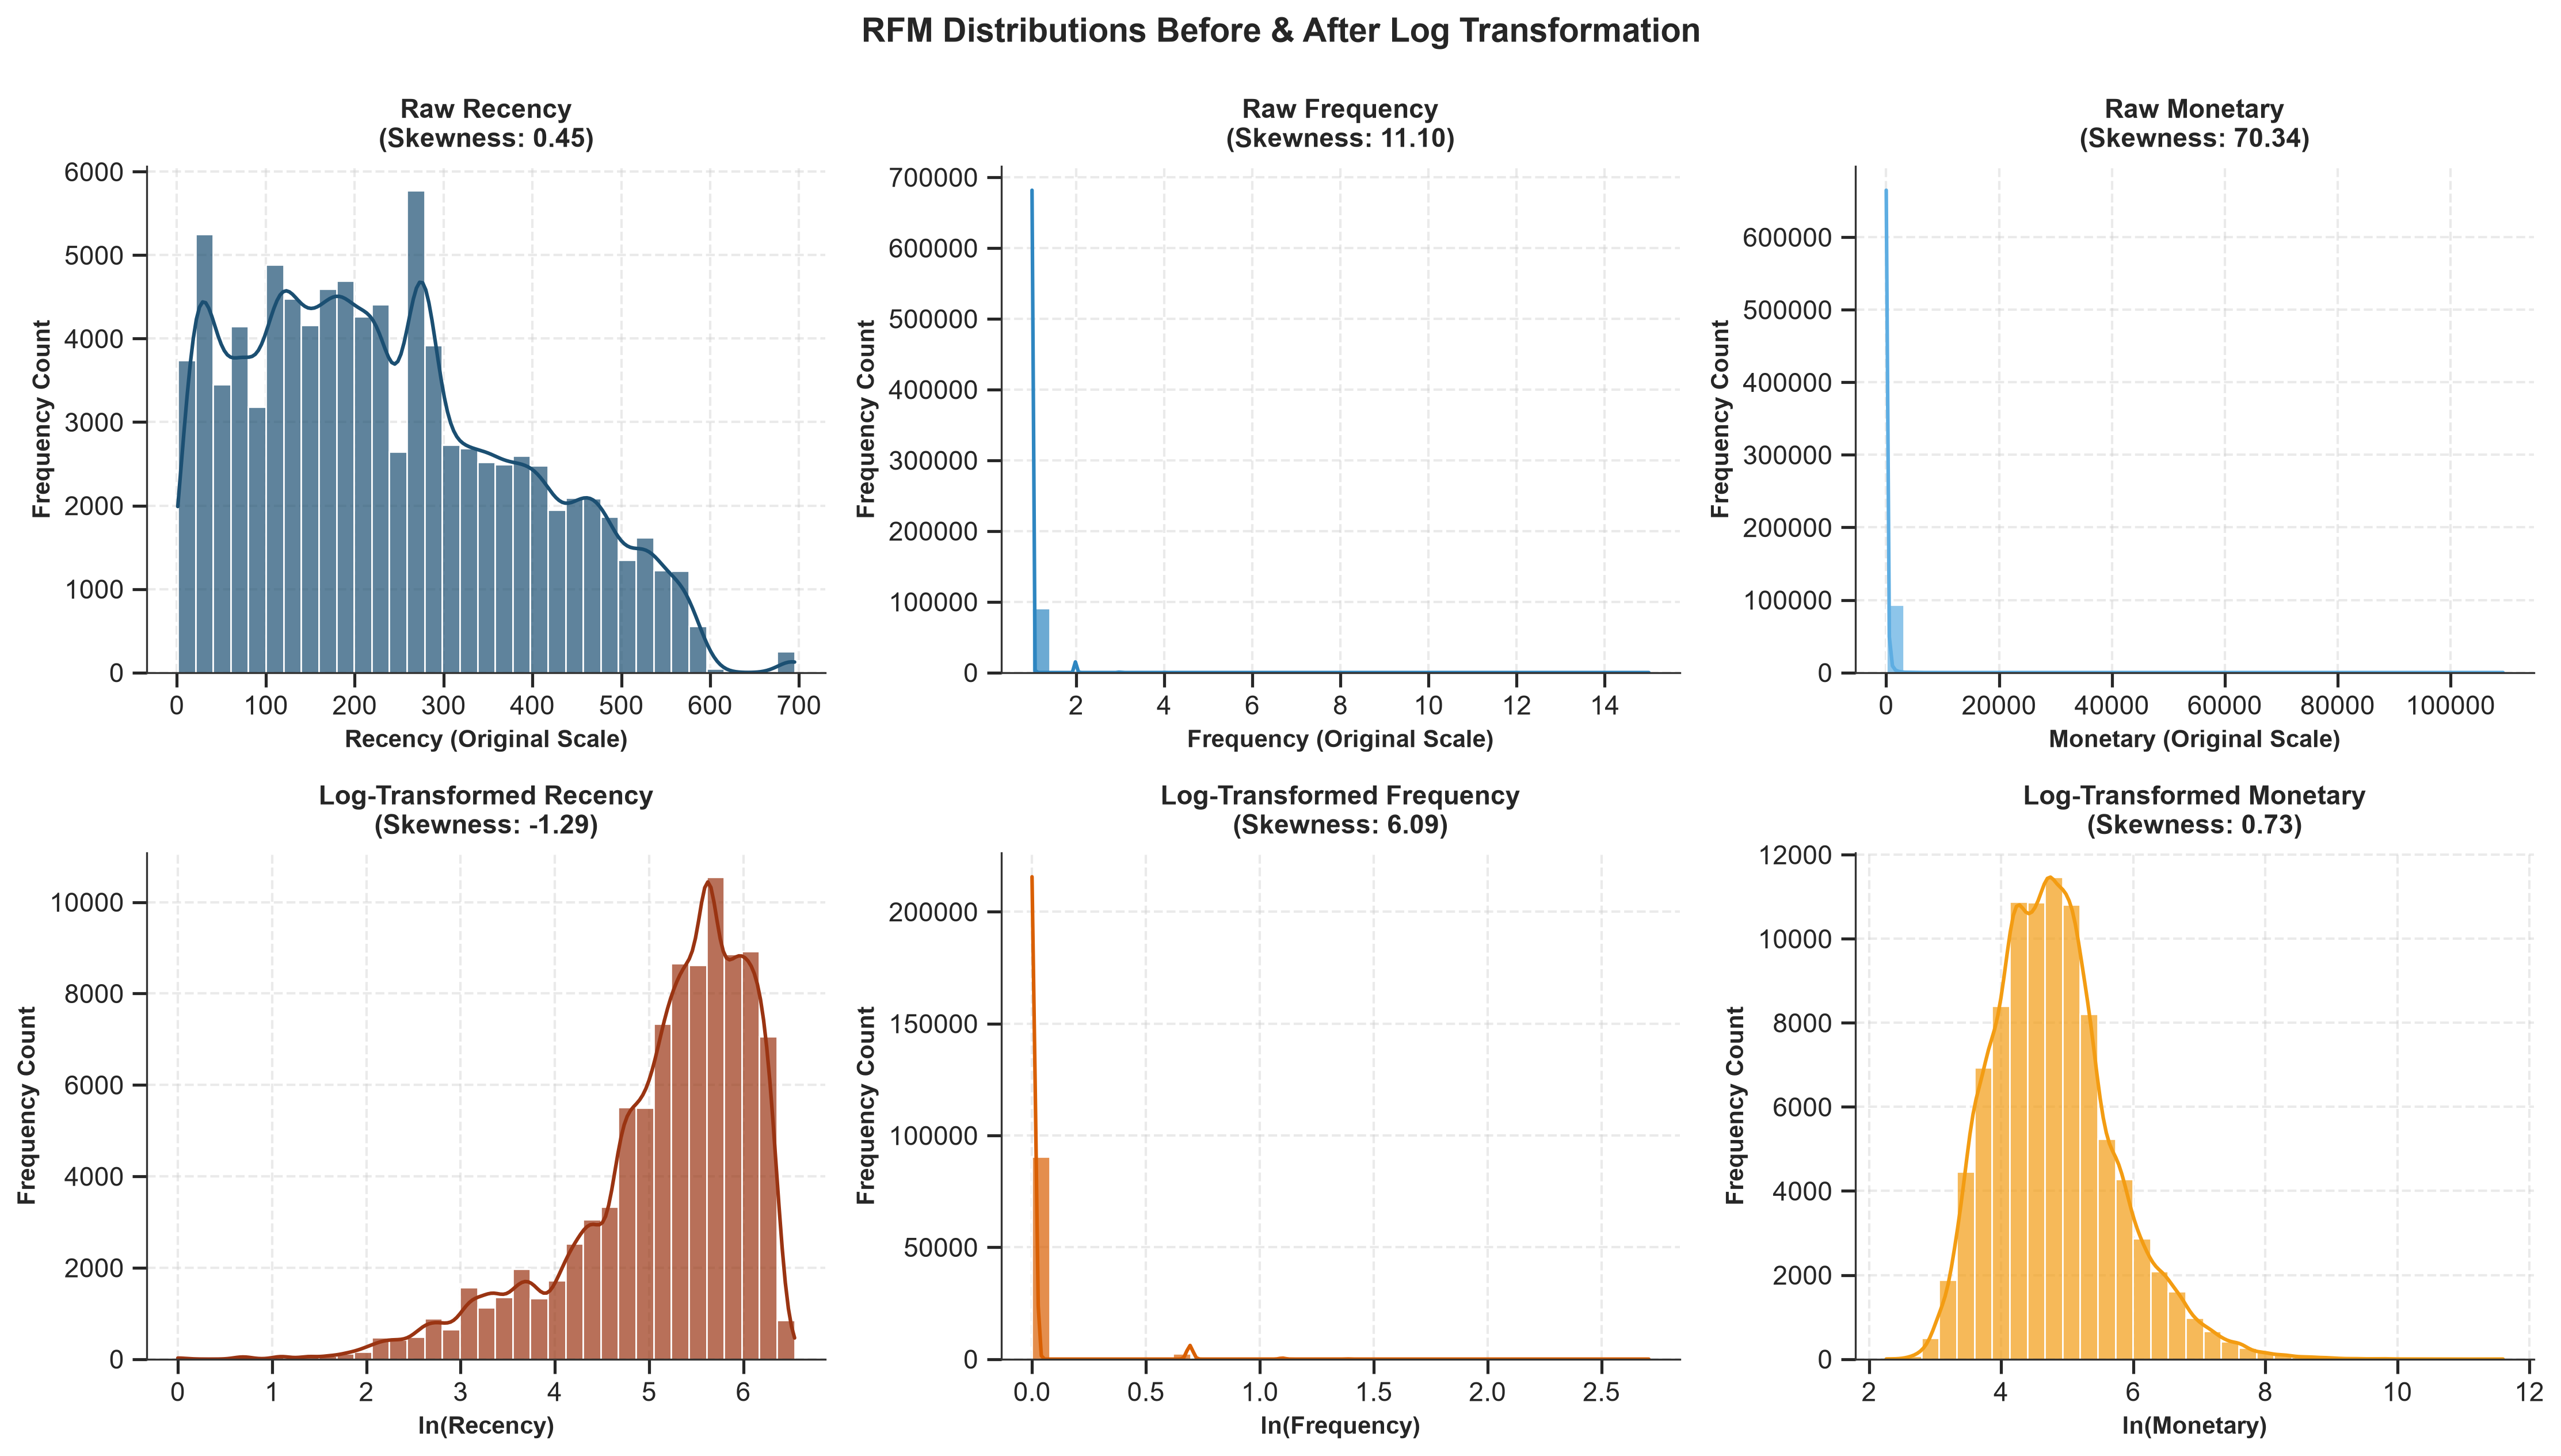

In [5]:
# Plotting Raw vs Log-Transformed distributions
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8.5), dpi=300)

features = ["Recency", "Frequency", "Monetary"]
colors_raw = ["#1B4F72", "#2E86C1", "#5DADE2"]
colors_log = ["#9A3412", "#D95F02", "#F39C12"]

# Row 1: Raw distributions
for i, col in enumerate(features):
    ax = axes[0, i]
    skew_val = rfm[col].skew()
    sns.histplot(rfm[col], bins=35, kde=True, color=colors_raw[i], ax=ax, edgecolor="white", alpha=0.7)
    ax.set_title(f"Raw {col}\n(Skewness: {skew_val:.2f})", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(f"{col} (Original Scale)", fontsize=10, fontweight="bold")
    ax.set_ylabel("Frequency Count", fontsize=10, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    sns.despine(ax=ax, top=True, right=True)

# Row 2: Log-Transformed distributions
for i, col in enumerate(features):
    ax = axes[1, i]
    skew_val = rfm_log[col].skew()
    sns.histplot(rfm_log[col], bins=35, kde=True, color=colors_log[i], ax=ax, edgecolor="white", alpha=0.7)
    ax.set_title(f"Log-Transformed {col}\n(Skewness: {skew_val:.2f})", fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel(f"ln({col})", fontsize=10, fontweight="bold")
    ax.set_ylabel("Frequency Count", fontsize=10, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)
    sns.despine(ax=ax, top=True, right=True)

plt.suptitle("RFM Distributions Before & After Log Transformation", fontsize=14, fontweight="bold", y=0.99)
plt.tight_layout()

results_dir = os.path.join("..", "Results") if os.path.exists(os.path.join("..", "Results")) else "Results"
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "rfm_skewness_and_transformations.png"), dpi=300, bbox_inches="tight")
plt.show()

## 4. Standard Scaling with `StandardScaler`
Standardize the log-transformed features to zero mean and unit variance.

In [7]:
# Instantiate and fit StandardScaler
scaler = StandardScaler()
rfm_scaled_arr = scaler.fit_transform(rfm_log)

# Create rfm_scaled DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled_arr,
    index=rfm.index,
    columns=rfm.columns
)

print("Scaled RFM Summary (rfm_scaled.describe()):")
display(rfm_scaled.describe())

# Save rfm_scaled to processed directory
processed_dir = os.path.join("..", "Data", "Processed") if os.path.exists(os.path.join("..", "Data", "Processed")) else os.path.join("Data", "Processed")
scaled_csv_path = os.path.join(processed_dir, "rfm_scaled.csv")
rfm_scaled.to_csv(scaled_csv_path)
print(f"\nSaved rfm_scaled to: {scaled_csv_path}")

Scaled RFM Summary (rfm_scaled.describe()):


,Recency,Frequency,Monetary
count,9.335700e+04,9.335700e+04,9.335700e+04
mean,-1.787069e-16,-4.498118e-17,1.366180e-16
std,1.000005e+00,1.000005e+00,1.000005e+00
min,-5.422841e+00,-1.721920e-01,-2.776582e+00
25%,-4.408379e-01,-1.721920e-01,-7.053402e-01
50%,2.459190e-01,-1.721920e-01,-8.014341e-02
75%,7.270230e-01,-1.721920e-01,5.540355e-01
max,1.460694e+00,2.100835e+01,7.436641e+00



Saved rfm_scaled to: ..\Data\Processed\rfm_scaled.csv
